In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df = pd.read_csv('AirfoilSelfNoise.csv')
df.describe()

,f,alpha,c,U_infinity,delta,SSPL
count,1503.000000,1503.000000,1503.000000,1503.000000,1503.000000,1503.000000
mean,2886.380572,6.782302,0.136548,50.860745,0.011140,124.835943
std,3152.573137,5.918128,0.093541,15.572784,0.013150,6.898657
min,200.000000,0.000000,0.025400,31.700000,0.000401,103.380000
25%,800.000000,2.000000,0.050800,39.600000,0.002535,120.191000
50%,1600.000000,5.400000,0.101600,39.600000,0.004957,125.721000
75%,4000.000000,9.900000,0.228600,71.300000,0.015576,129.995500
max,20000.000000,22.200000,0.304800,71.300000,0.058411,140.987000


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1503 entries, 0 to 1502
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   f           1503 non-null   int64  
 1   alpha       1503 non-null   float64
 2   c           1503 non-null   float64
 3   U_infinity  1503 non-null   float64
 4   delta       1503 non-null   float64
 5   SSPL        1503 non-null   float64
dtypes: float64(5), int64(1)
memory usage: 70.6 KB


In [11]:
df.head()

,f,alpha,c,U_infinity,delta,SSPL
0,800,0.0,0.3048,71.3,0.002663,126.201
1,1000,0.0,0.3048,71.3,0.002663,125.201
2,1250,0.0,0.3048,71.3,0.002663,125.951
3,1600,0.0,0.3048,71.3,0.002663,127.591
4,2000,0.0,0.3048,71.3,0.002663,127.461


/home/jiteich/repos/ceia/ml/.venv/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


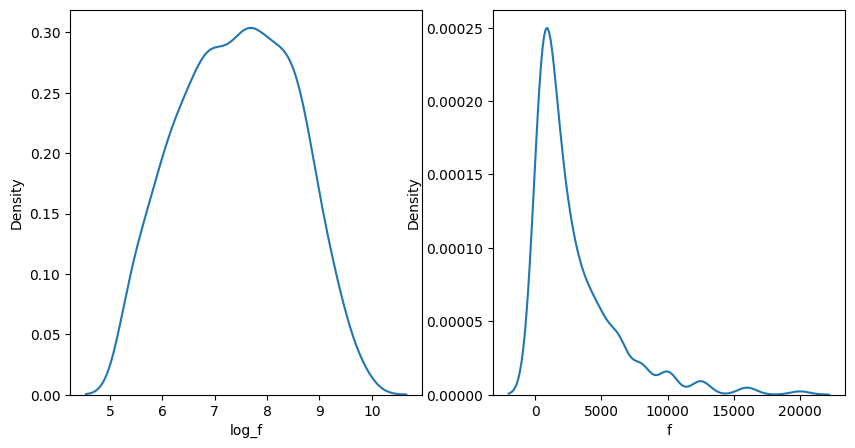

5.298317366548036


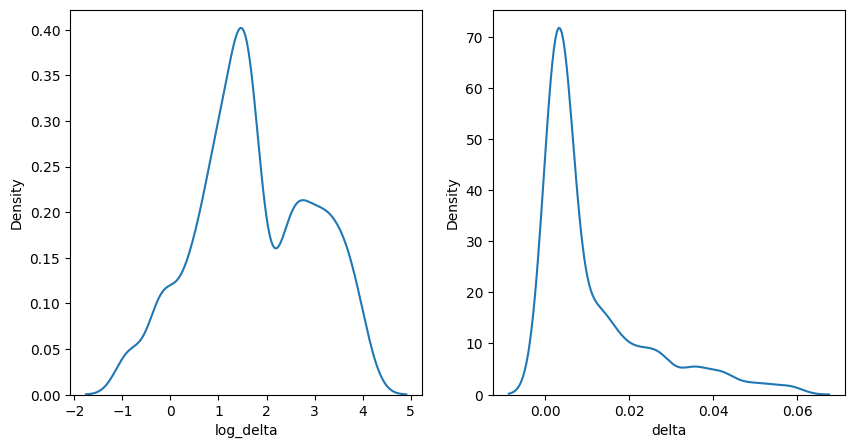

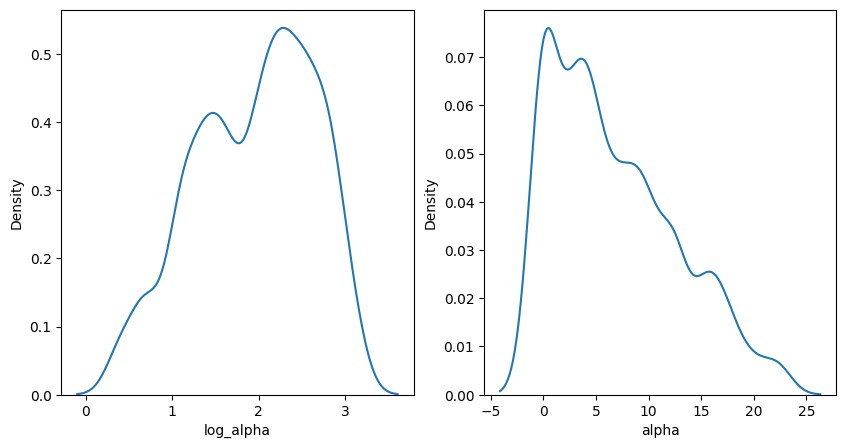

-inf


In [167]:
df['log_f'] = np.log(df['f'])
df['log_delta'] = np.log(1000*df['delta'])
df['log_alpha'] = np.log(df['alpha'])


fig, axs = plt.subplots(1,2,figsize=(10,5))
for idx, col in enumerate(['log_f', 'f']):
    sns.kdeplot(data=df, x=col, ax=axs[idx])
plt.show()
print(df['log_f'].min())

fig, axs = plt.subplots(1,2,figsize=(10,5))
for idx, col in enumerate(['log_delta', 'delta']):
    sns.kdeplot(data=df, x=col, ax=axs[idx])
plt.show()

fig, axs = plt.subplots(1,2,figsize=(10,5))
for idx, col in enumerate(['log_alpha', 'alpha']):
    sns.kdeplot(data=df, x=col, ax=axs[idx])
plt.show()
print(df['log_alpha'].min())

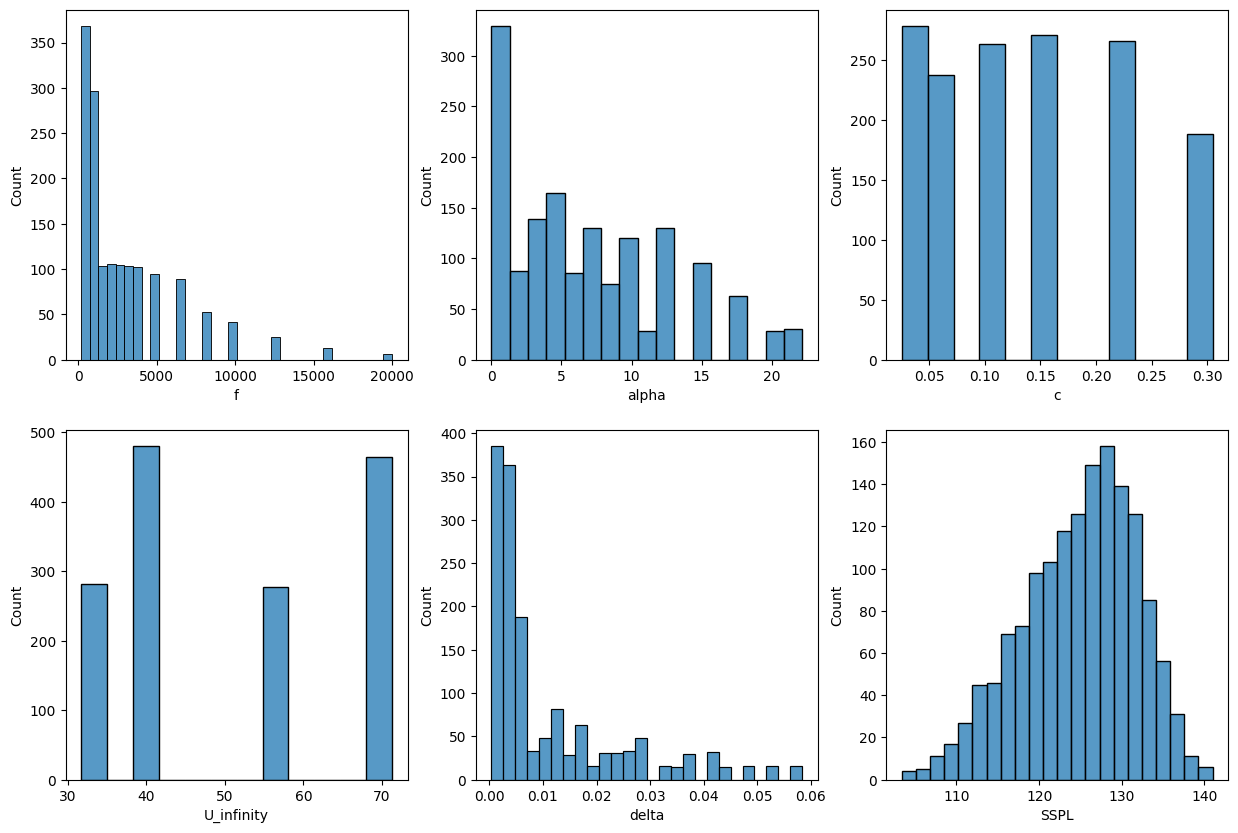

In [26]:
fig, axs = plt.subplots(2,3,figsize=(15,10))
for idx, col in enumerate(df.columns):
    sns.histplot(data=df, x=col, ax=axs[idx//3][idx%3])

In [33]:
for col in ['c', 'U_infinity']:
    print(df[col].value_counts())

c
0.0254    278
0.1524    271
0.2286    266
0.1016    263
0.0508    237
0.3048    188
Name: count, dtype: int64
U_infinity
39.6    480
71.3    465
31.7    281
55.5    277
Name: count, dtype: int64


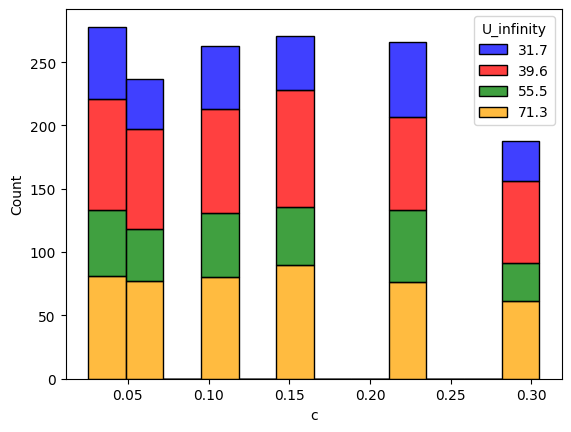

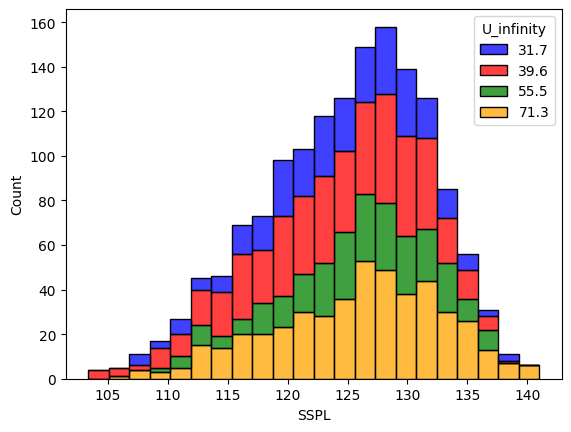

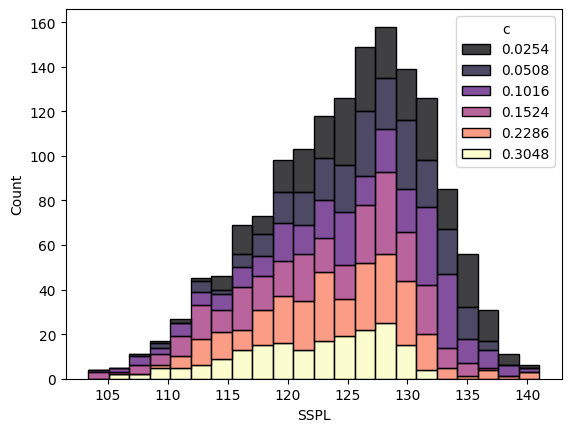

In [81]:
color_palette = {
                 39.6: 'red',
                 31.7: 'blue',
                 55.5: 'green',
                 71.3: 'orange'}
sns.histplot(data=df, x='c', hue='U_infinity', multiple='stack', palette=color_palette)
plt.show()
sns.histplot(data=df, x='SSPL', hue='U_infinity', multiple='stack', palette=color_palette)
plt.show()
sns.histplot(data=df, x='SSPL', hue='c', multiple='stack', palette='magma')
plt.show()

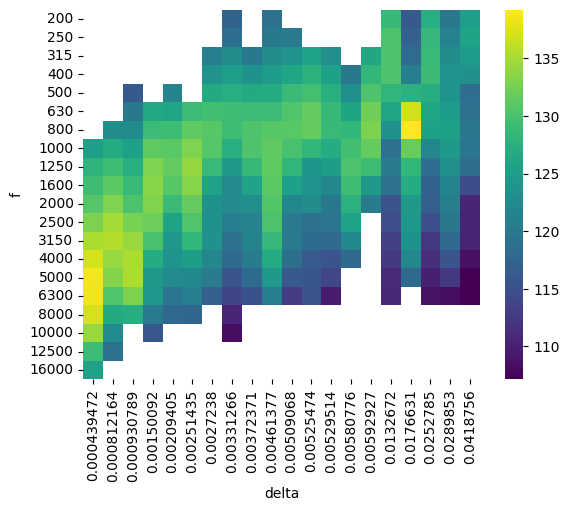

In [105]:
df_pivoted = df[df['U_infinity'] < 39].pivot_table(index='f', columns='delta', values='SSPL', aggfunc='mean')
# sspl = df_pivoted.to_numpy()
# u_inf, c = np.meshgrid(df_pivoted.columns, df_pivoted.index)
sns.heatmap(data=df_pivoted, cmap='viridis')
plt.show()

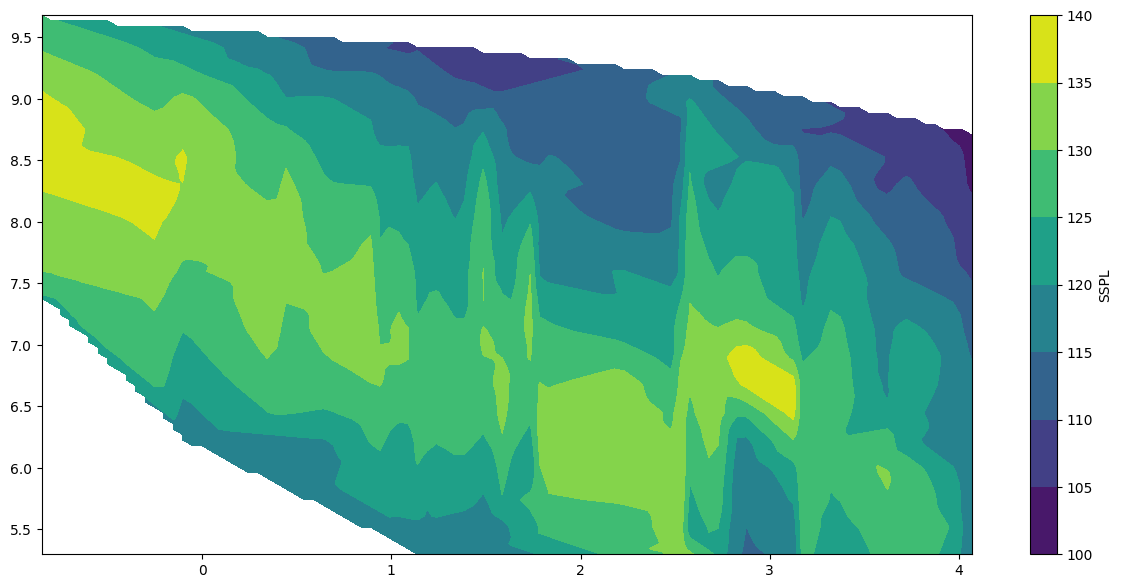

In [160]:
from scipy.interpolate import griddata

df_pivoted = df[df['U_infinity'] == 39.6].pivot_table(index='log_f', columns='log_delta', values='SSPL', aggfunc='mean')

fig, axs = plt.subplots(1,1,figsize=(15,7))

# sns.heatmap(data=df_pivoted, cmap='viridis', ax=axs[0])

Z = df_pivoted.to_numpy()
X, Y = np.meshgrid(df_pivoted.columns, df_pivoted.index)
X, Y, Z = X.ravel(), Y.ravel(), Z.ravel()
mask = ~np.isnan(Z)  # Keep only valid points
X, Y, Z = X[mask], Y[mask], Z[mask]
range_x, range_y = np.linspace(X.min(), X.max(), 100), np.linspace(Y.min(), Y.max(), 100)
grid_x, grid_y = np.meshgrid(range_x, range_y)
grid_z = griddata(
    points=(X, Y), 
    values=Z, 
    xi=(grid_x, grid_y), 
    # method='cubic'
    # method='nearest'
    method='linear'
)

# cf = axs[1].contourf(grid_x, grid_y, grid_z)
# cbar = fig.colorbar(cf, ax=axs[1])
cf = axs.contourf(grid_x, grid_y, grid_z)
cbar = fig.colorbar(cf, ax=axs)
cbar.set_label('SSPL')
# axs[1].colorbar()
# plt.colorbar() /
plt.show()

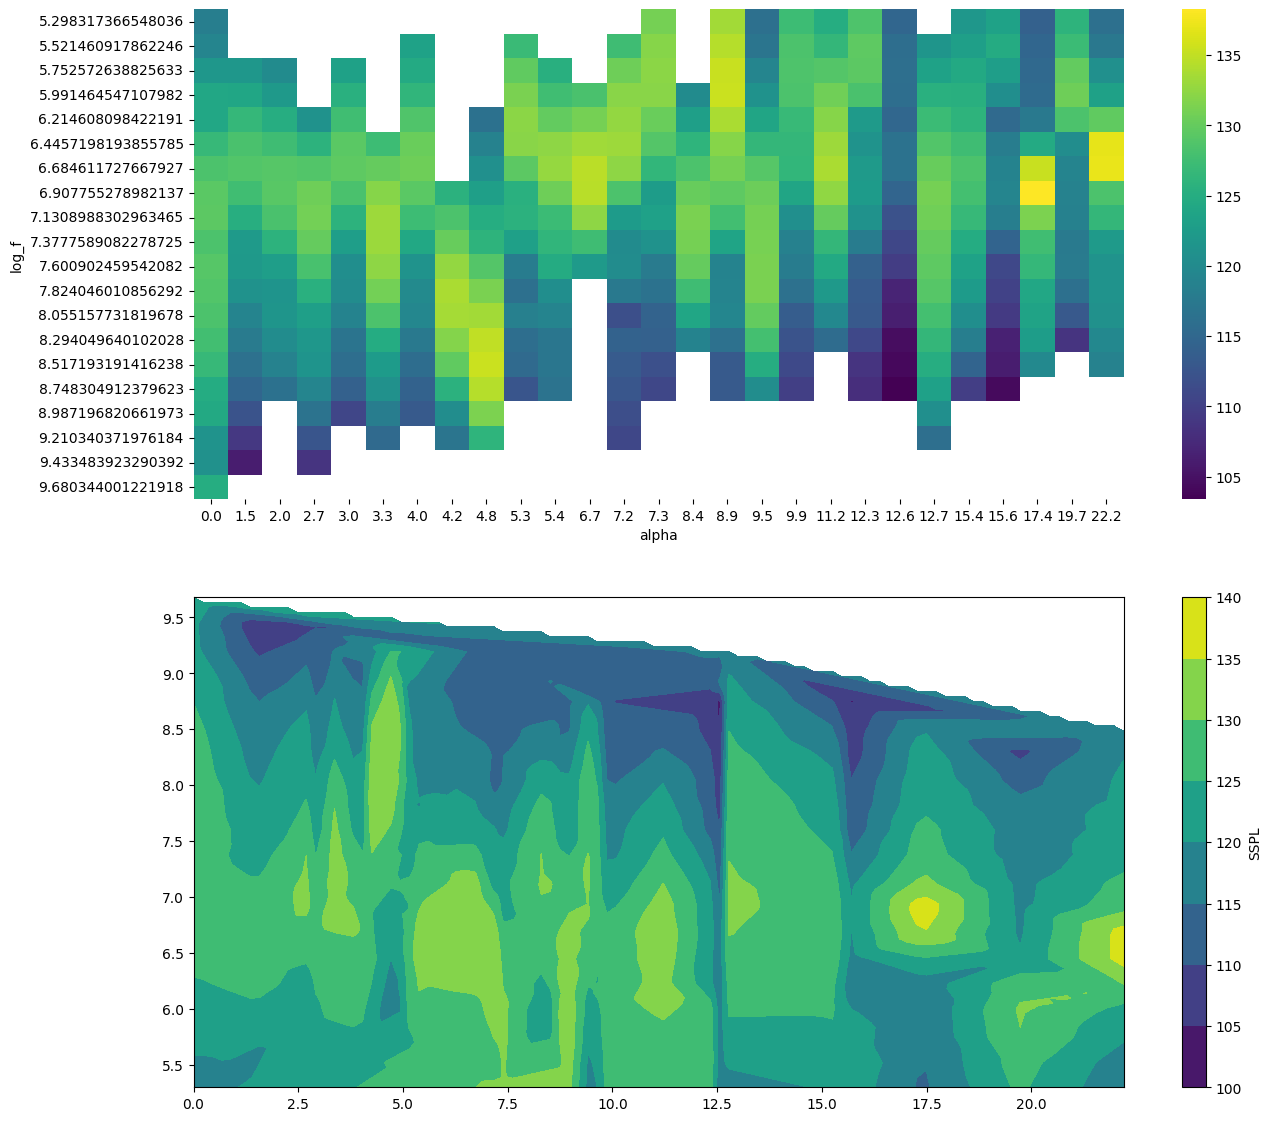

In [172]:
df_pivoted = df[df['U_infinity'] == 39.6].pivot_table(index='log_f', columns='alpha', values='SSPL', aggfunc='mean')

fig, axs = plt.subplots(2,1,figsize=(15,14))

sns.heatmap(data=df_pivoted, cmap='viridis', ax=axs[0])

Z = df_pivoted.values
X, Y = np.meshgrid(df_pivoted.columns, df_pivoted.index)
X, Y, Z = X.ravel(), Y.ravel(), Z.ravel()
mask = ~np.isnan(Z)  # Keep only valid points
X, Y, Z = X[mask], Y[mask], Z[mask]

range_x, range_y = np.linspace(X.min(), X.max(), 100), np.linspace(Y.min(), Y.max(), 100)
grid_x, grid_y = np.meshgrid(range_x, range_y)
grid_z = griddata(
    points=(X, Y), 
    values=Z, 
    xi=(grid_x, grid_y), 
    # method='cubic'
    # method='nearest'
    method='linear'
)

# cf = axs.contourf(grid_x, grid_y, grid_z)
# cbar = fig.colorbar(cf, ax=axs)
cf = axs[1].contourf(grid_x, grid_y, grid_z)
cbar = fig.colorbar(cf, ax=axs[1])
cbar.set_label('SSPL')
plt.show()

In [ ]:
df_pivoted = df.pivot_table(index='U_infinity', columns='c', values='SSPL', aggfunc='mean')
# sspl = df_pivoted.to_numpy()
# u_inf, c = np.meshgrid(df_pivoted.columns, df_pivoted.index)
sns.heatmap(data=df_pivoted, cmap='viridis')
plt.show()

Z = df_pivoted.to_numpy()
X, Y = np.meshgrid(df_pivoted.columns, df_pivoted.index)

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none', alpha=0.8)
fig.colorbar(surf, shrink=0.5, aspect=5)

ax.set_xlabel('U_inf')
ax.set_ylabel('c')
ax.set_zlabel('SSPL')

plt.show()

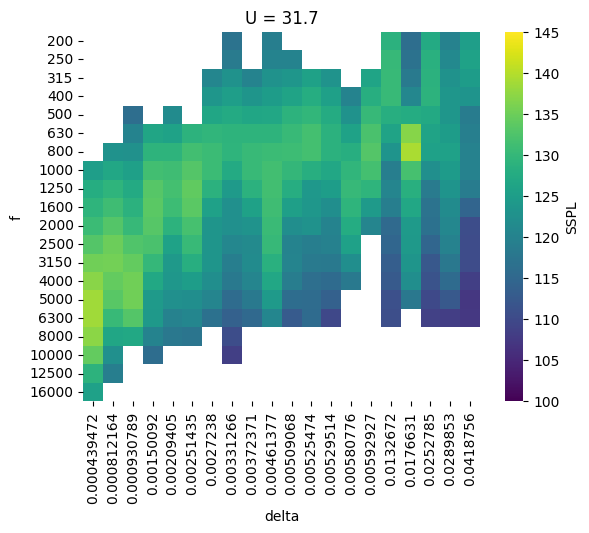

SSPL mean for U_inf=31.7 -> 124.27766548042706


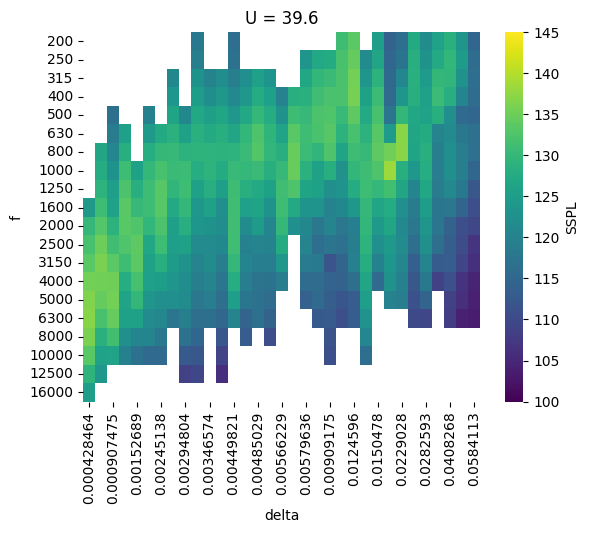

SSPL mean for U_inf=39.6 -> 123.67020000000001


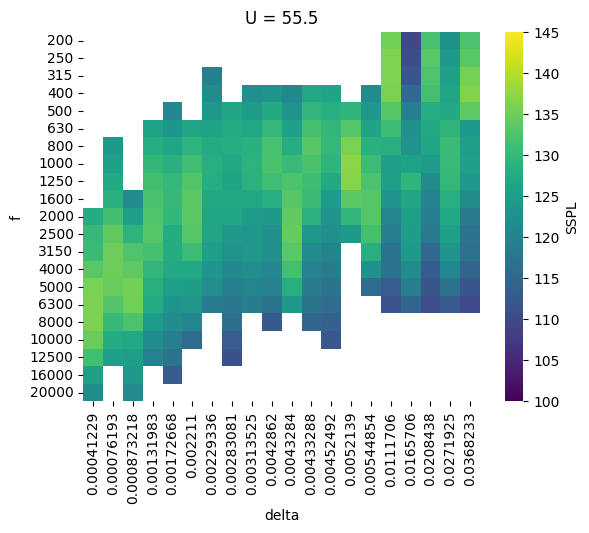

SSPL mean for U_inf=55.5 -> 125.69583754512637


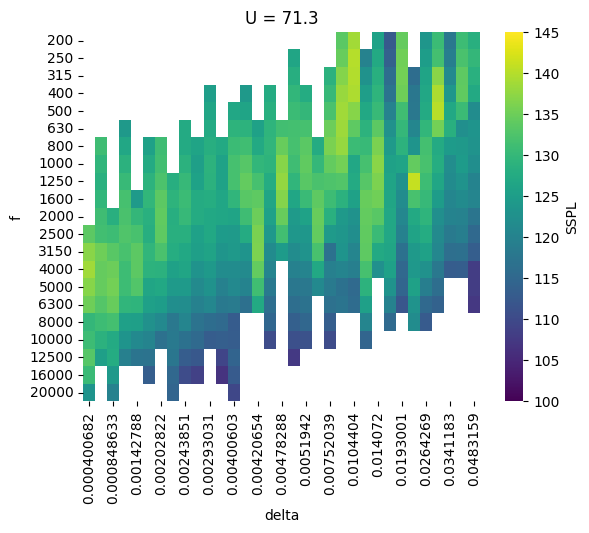

SSPL mean for U_inf=71.3 -> 125.86441935483872


In [87]:
for U_inf in [31.7, 39.6, 55.5, 71.3]:
    df_pivoted = df[df['U_infinity']==U_inf].pivot_table(index='f', columns='delta', values='SSPL', aggfunc='mean')
    sns.heatmap(data=df_pivoted, cmap='viridis', vmin=100, vmax=145, cbar_kws={'label': 'SSPL'})
    plt.title(f'U = {U_inf}')
    plt.show()

    sspl_mean = df[df["U_infinity"]==U_inf]['SSPL'].mean()
    print(f"SSPL mean for U_inf={U_inf} -> {sspl_mean}")


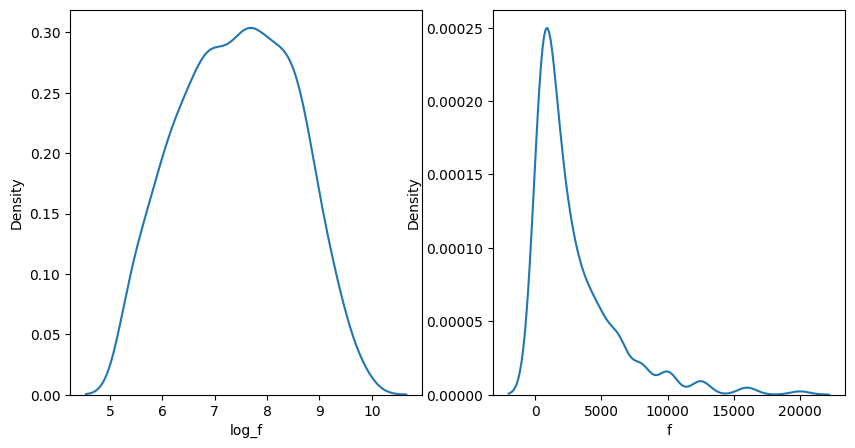

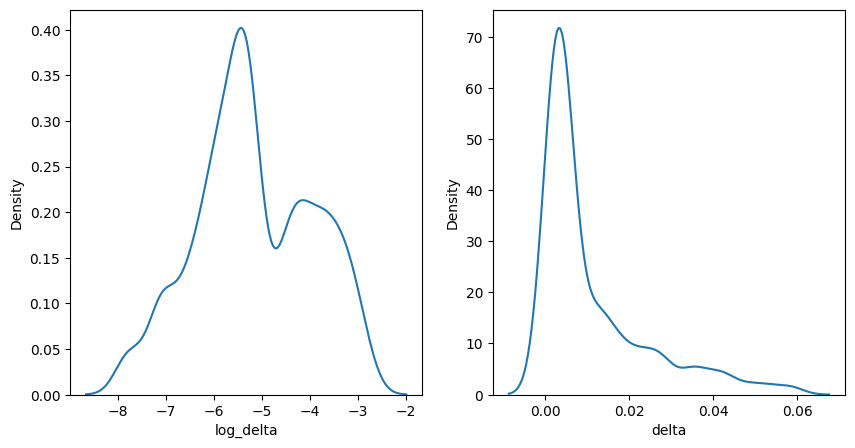

In [32]:
df['log_f'] = np.log(df['f'])
df['log_delta'] = np.log(df['delta'])

fig, axs = plt.subplots(1,2,figsize=(10,5))
for idx, col in enumerate(['log_f', 'f']):
    sns.kdeplot(data=df, x=col, ax=axs[idx])
plt.show()

fig, axs = plt.subplots(1,2,figsize=(10,5))
for idx, col in enumerate(['log_delta', 'delta']):
    sns.kdeplot(data=df, x=col, ax=axs[idx])
plt.show()

Hagamos una regresión lineal para tener un punto de partida.

In [72]:
import sklearn
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (mean_absolute_error, r2_score,
                             root_mean_squared_error, 
                             mean_absolute_percentage_error)

X_cols = ['f', 'alpha', 'c', 'U_infinity', 'delta']
X = df[X_cols]
y_col = 'SSPL'
y = df[[y_col]]

x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

X_train = x_scaler.fit_transform(X_train)
y_train = y_scaler.fit_transform(y_train)
X_test = x_scaler.transform(X_test)
y_test = y_scaler.transform(y_test)

lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

yhat_train = lin_reg.predict(X_train)
mae_train = mean_absolute_error(y_train, yhat_train)
print("Linear Regression:")
print(f"MAE train = {mae_train:3f}")

yhat_test = lin_reg.predict(X_test)
mae_test = mean_absolute_error(y_test, yhat_test)
print(f"MAE = {mae_test:3f}")
rmse_test = root_mean_squared_error(y_test, yhat_test)
print(f"RMSE = {rmse_test:3f}")
r2_test = r2_score(y_test, yhat_test)
print(f"R2 = {r2_test:3f}")

Linear Regression:
MAE train = 0.533310
MAE = 0.525097
RMSE = 0.682072
R2 = 0.454245


In [219]:
from sklearn.tree import DecisionTreeRegressor

tree_regressor = DecisionTreeRegressor(
    min_samples_leaf = 5,
    min_samples_split = 10,
    random_state=42
)
tree_regressor.fit(X_train, y_train)

print("Decision Tree Regressor:")

yhat_train = tree_regressor.predict(X_train)
mae_train = mean_absolute_error(y_train, yhat_train)
print(f"MAE train = {mae_train:3f}")

yhat_test = tree_regressor.predict(X_test)
mae_test = mean_absolute_error(y_test, yhat_test)
print(f"MAE = {mae_test:3f}")
rmse_test = root_mean_squared_error(y_test, yhat_test)
print(f"RMSE = {rmse_test:3f}")
r2_test = r2_score(y_test, yhat_test)
print(f"R2 = {r2_test:3f}")

Decision Tree Regressor:
MAE train = 0.226572
MAE = 0.346219
RMSE = 0.463196
R2 = 0.802391


In [231]:
from sklearn.ensemble import BaggingRegressor
bagging_regressor = BaggingRegressor(
    estimator=DecisionTreeRegressor(),
    n_estimators=10,
    random_state=42,
    n_jobs=10
)
bagging_regressor.fit(X_train, y_train)

print("Bagging Regressor:")

yhat_train = bagging_regressor.predict(X_train)
mae_train = mean_absolute_error(y_train, yhat_train)
print(f"MAE train = {mae_train:3f}")

yhat_test = bagging_regressor.predict(X_test)
mae_test = mean_absolute_error(y_test, yhat_test)
print(f"MAE = {mae_test:3f}")
rmse_test = root_mean_squared_error(y_test, yhat_test)
print(f"RMSE = {rmse_test:3f}")
r2_test = r2_score(y_test, yhat_test)
print(f"R2 = {r2_test:3f}")

Bagging Regressor:
MAE train = 0.082112
MAE = 0.199059
RMSE = 0.276175
R2 = 0.929750


/home/jiteich/repos/ceia/ml/.venv/lib/python3.11/site-packages/sklearn/ensemble/_bagging.py:583: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  return column_or_1d(y, warn=True)


In [222]:
from sklearn.ensemble import RandomForestRegressor
rf_regressor = RandomForestRegressor(random_state=42)

rf_regressor.fit(X_train, y_train)

print("Random Forest Regressor:")

yhat_train = rf_regressor.predict(X_train)
mae_train = mean_absolute_error(y_train, yhat_train)
print(f"MAE train = {mae_train:3f}")

yhat_test = rf_regressor.predict(X_test)
mae_test = mean_absolute_error(y_test, yhat_test)
print(f"MAE = {mae_test:3f}")
rmse_test = root_mean_squared_error(y_test, yhat_test)
print(f"RMSE = {rmse_test:3f}")
r2_test = r2_score(y_test, yhat_test)
print(f"R2 = {r2_test:3f}")

/home/jiteich/repos/ceia/ml/.venv/lib/python3.11/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Random Forest Regressor:
MAE train = 0.069127
MAE = 0.179064
RMSE = 0.253979
R2 = 0.940588


In [ ]:
import xgboost as xgb

xgb_regressor = xgb.XGBRegressor(
    objective='reg:squarederror',precomputed
    random_state=42,
    n_jobs = 10
)

xgb_regressor.fit(X_train, y_train)

print("XGBoost Regressor:")

yhat_train = xgb_regressor.predict(X_train)
mae_train = mean_absolute_error(y_train, yhat_train)
print(f"MAE train = {mae_train:3f}")

yhat_test = xgb_regressor.predict(X_test)
mae_test = mean_absolute_error(y_test, yhat_test)
print(f"MAE = {mae_test:3f}")
rmse_test = root_mean_squared_error(y_test, yhat_test)
print(f"RMSE = {rmse_test:3f}")
r2_test = r2_score(y_test, yhat_test)
print(f"R2 = {r2_test:3f}")

XGBoost Regressor:
MAE train = 0.033683
MAE = 0.147862
RMSE = 0.226141
R2 = 0.952899


In [116]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (mean_absolute_error, r2_score,
                             root_mean_squared_error, 
                             mean_absolute_percentage_error)
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import BaggingRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
import xgboost as xgb
from sklearn.ensemble import VotingRegressor

models = {
    'linear regression' : {
        'model' : LinearRegression()
    },
    'decision tree regressor' : {
        'model' : DecisionTreeRegressor(
            min_samples_leaf = 5,
            min_samples_split = 10,
            random_state=42
        )
    },
    'bagging' : {
        'model' : BaggingRegressor(
            estimator=DecisionTreeRegressor(),
            n_estimators=10,
            random_state=42,
            n_jobs=10
        )
    },
    'random forest' : {
        'model' : RandomForestRegressor(random_state=42)
    },
    'xgboost' : {
        'model' : xgb.XGBRegressor(
            objective='reg:squarederror',
            random_state=42,
            n_jobs = 10
        )
    },
    'SVR' : {
        'model' : SVR(
            kernel='rbf',
            C = 50,
            gamma = 100
        )
    },
    'Voting Regressor' : {
        'model' : VotingRegressor(
            estimators = [
                ('linear regression', LinearRegression()),
                ('decision tree', DecisionTreeRegressor(min_samples_leaf = 5, min_samples_split = 10, random_state=42)),
                ('random forest', RandomForestRegressor()),
                ('xgboost', xgb.XGBRegressor(objective='reg:squarederror', random_state=42, n_jobs = 10)),
                ('SVR', SVR(kernel='rbf', C = 50, gamma = 100))
            ],
            # voting = 'hard',
            n_jobs = 10
        )
    }
}

def compute_metrics(y_train, yhat_train, y_test, yhat_test):
    mae_train = mean_absolute_error(y_train, yhat_train)
    rmse_train = root_mean_squared_error(y_train, yhat_train)
    r2_train = r2_score(y_train, yhat_train)
    mae_test = mean_absolute_error(y_test, yhat_test)
    rmse_test = root_mean_squared_error(y_test, yhat_test)
    r2_test = r2_score(y_test, yhat_test)
    return mae_train, rmse_train, r2_train, mae_test, rmse_test, r2_test

results = {}
for model_name in models.keys():
    model_dict = models[model_name]
    model = model_dict['model']
    model.fit(X_train, y_train)
    yhat_train = model.predict(X_train)
    yhat_test = model.predict(X_test)
    results[model_name] = {}
    results[model_name]['yhat_train'] = yhat_train 
    results[model_name]['yhat_test'] = yhat_test 
    model_dict['mae_train'], model_dict['rmse_train'], model_dict['r2_train'], model_dict['mae_test'], model_dict['rmse_test'], model_dict['r2_test'] = compute_metrics(y_train, yhat_train, y_test, yhat_test)



/home/jiteich/repos/ceia/ml/.venv/lib/python3.11/site-packages/sklearn/ensemble/_bagging.py:583: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  return column_or_1d(y, warn=True)
/home/jiteich/repos/ceia/ml/.venv/lib/python3.11/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/home/jiteich/repos/ceia/ml/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/jiteich/repos/ceia/ml/.venv/lib/python3.11/site-packages/sklearn/ensemble/_voting.py:676: DataConversionWarning: A column-vector y 

In [117]:
df_models = pd.DataFrame(models).transpose()
df_models

,model,mae_train,rmse_train,r2_train,mae_test,rmse_test,r2_test
linear regression,LinearRegression(),0.53331,0.68712,0.527867,0.525097,0.682072,0.454245
decision tree regressor,"DecisionTreeRegressor(min_samples_leaf=5, min_...",0.225238,0.301911,0.908849,0.338692,0.449165,0.763327
bagging,(DecisionTreeRegressor(random_state=1952926171...,0.082074,0.126481,0.984002,0.199334,0.278202,0.909206
random forest,"(DecisionTreeRegressor(max_features=1.0, rando...",0.06687,0.094333,0.991101,0.186862,0.260838,0.920186
xgboost,"XGBRegressor(base_score=None, booster=None, ca...",0.035955,0.049477,0.997552,0.156703,0.22665,0.939738
SVR,"SVR(C=50, gamma=100)",0.09152,0.094041,0.991156,0.512901,0.712593,0.404311
Voting Regressor,VotingRegressor(estimators=[('linear regressio...,0.151183,0.193356,0.962614,0.271848,0.340322,0.864132


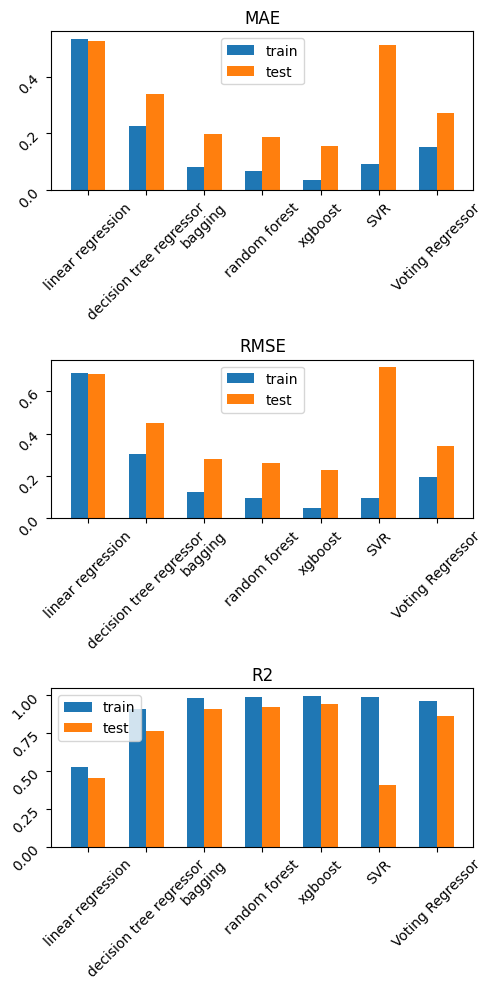

In [118]:
fig, axs = plt.subplots(3,1, figsize=(5,10))

x_pos = np.arange(len(df_models.index))
bar_width = 0.3
x_ticks = list(df_models.index)
# MAE
axs[0].bar(x_pos-bar_width/2, df_models['mae_train'],bar_width, label='train')
axs[0].bar(x_pos+bar_width/2, df_models['mae_test'],bar_width, label='test')
axs[0].tick_params(rotation=45)
axs[0].set_title('MAE')
axs[0].set_xticks(x_pos, x_ticks)
axs[0].legend()

# RMSE
axs[1].bar(x_pos-bar_width/2, df_models['rmse_train'],bar_width, label='train')
axs[1].bar(x_pos+bar_width/2, df_models['rmse_test'],bar_width, label='test')
axs[1].tick_params(rotation=45)
axs[1].set_title('RMSE')
axs[1].set_xticks(x_pos, x_ticks)
axs[1].legend()

# R2
axs[2].bar(x_pos-bar_width/2, df_models['r2_train'],bar_width, label='train')
axs[2].bar(x_pos+bar_width/2, df_models['r2_test'],bar_width, label='test')
axs[2].tick_params(rotation=45)
axs[2].set_title('R2')
axs[2].set_xticks(x_pos, x_ticks)
axs[2].legend()


plt.tight_layout()

Text(0, 0.5, 'True')

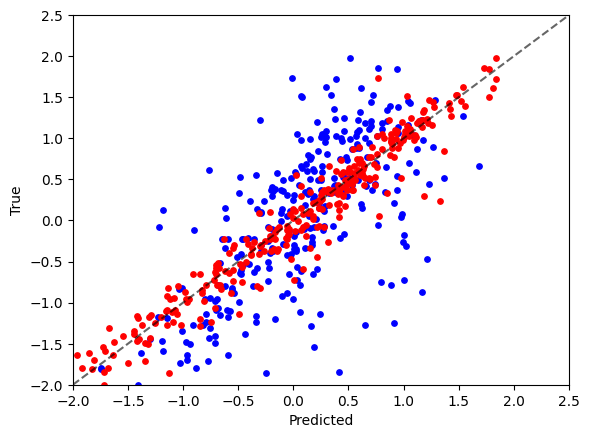

In [119]:
plt.scatter(results['linear regression']['yhat_test'], y_test, color='blue', s=15)
plt.scatter(results['xgboost']['yhat_test'], y_test, color='red', s=15)
plt.plot([-2,2.5],[-2,2.5], color='black', linestyle='dashed', alpha=0.6)
plt.xlim(-2,2.5)
plt.ylim(-2,2.5)
plt.xlabel('Predicted')
plt.ylabel('True')

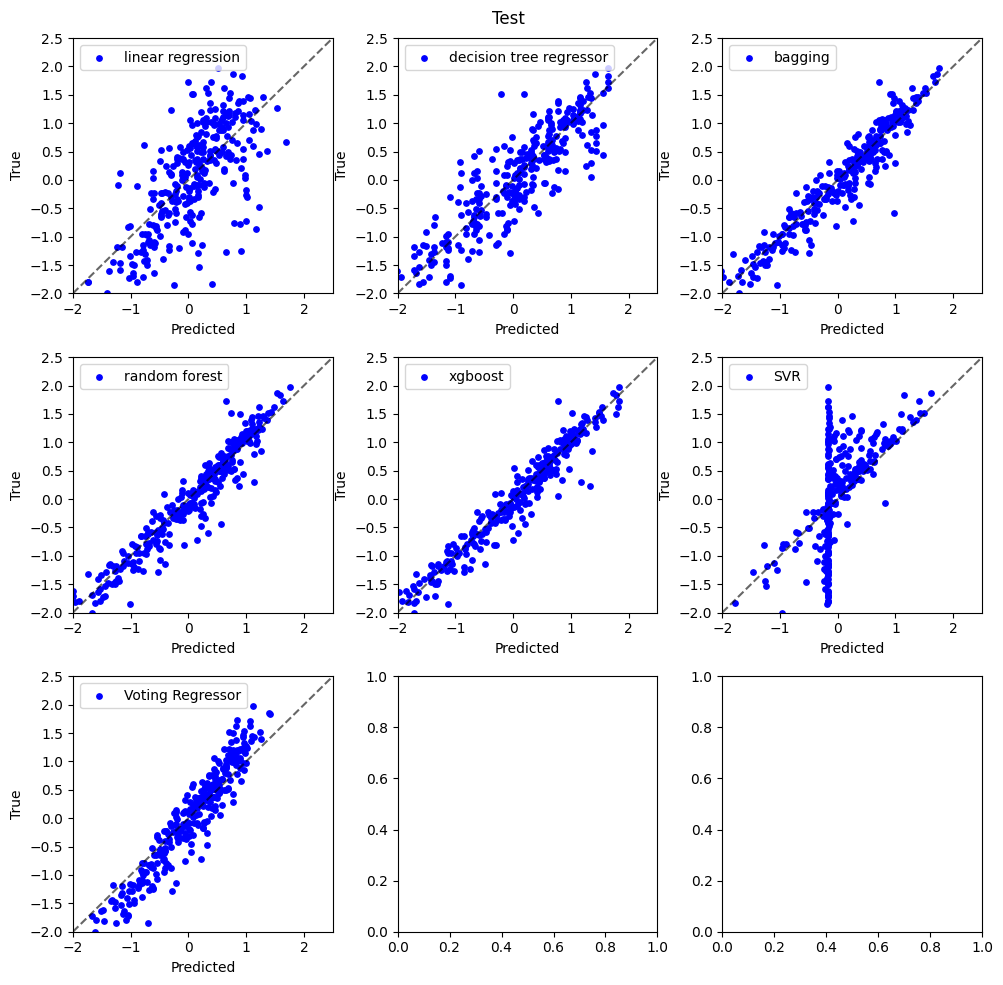

In [120]:
fig, axs = plt.subplots(3,3,figsize=(10,10))
# axs[1][2].axis('off')
for idx, model in enumerate(list(results.keys())):
    ax = axs[idx//3][idx%3]
    ax.scatter(results[model]['yhat_test'], y_test, color='blue', s=15, label=model)
    ax.legend()

    ax.plot([-2,2.5],[-2,2.5], color='black', linestyle='dashed', alpha=0.6)
    ax.set_xlim(-2,2.5)
    ax.set_ylim(-2,2.5)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
fig.suptitle('Test')
plt.tight_layout()
plt.show()

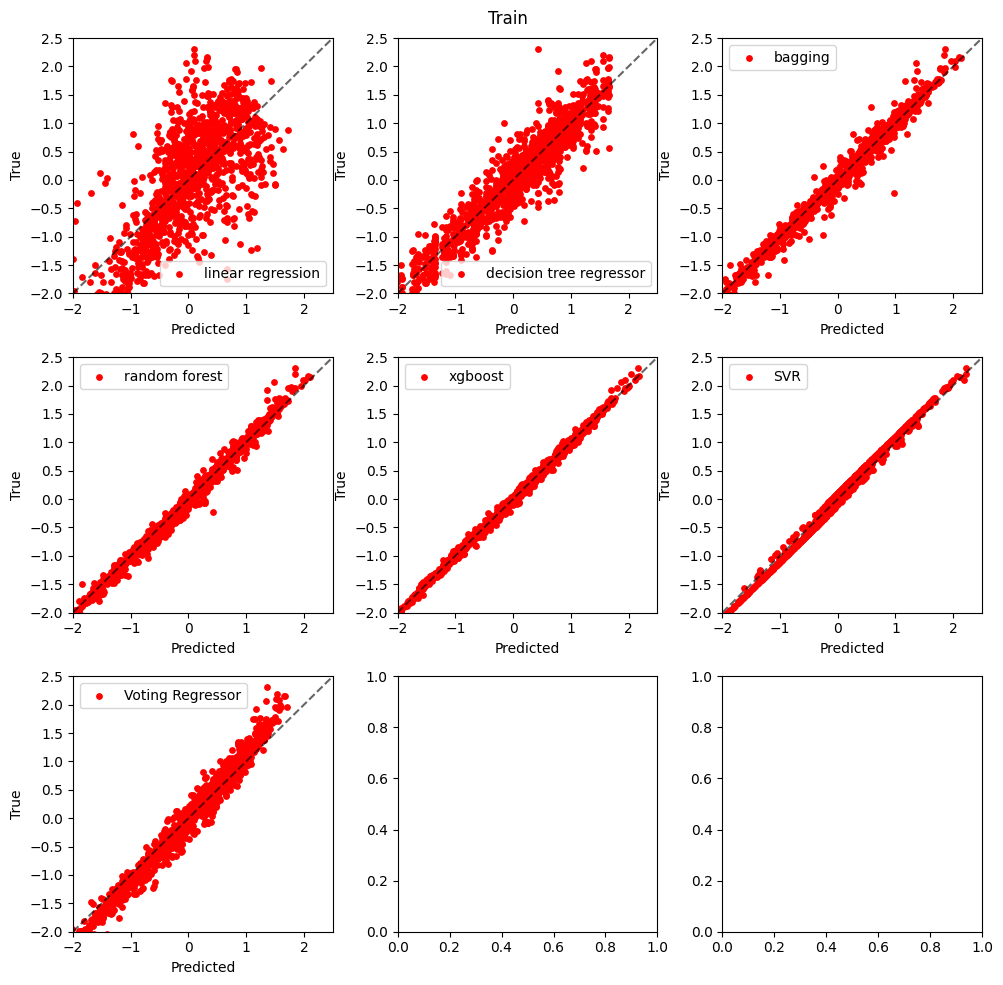

In [122]:
fig, axs = plt.subplots(3,3,figsize=(10,10))
# axs[1][2].axis('off')
for idx, model in enumerate(list(results.keys())):
    ax = axs[idx//3][idx%3]
    ax.scatter(results[model]['yhat_train'], y_train, color='red', s=15, label=model)
    ax.legend()

    ax.plot([-2,2.5],[-2,2.5], color='black', linestyle='dashed', alpha=0.6)
    ax.set_xlim(-2,2.5)
    ax.set_ylim(-2,2.5)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
fig.suptitle('Train')
plt.tight_layout()
plt.show()